A script for some figures for cosyne
- make a heatmap of activity aligned across homings
- plot escapes
- plot homings

In [1]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.process.process import Process
from JR_test_scripts.escape.escape_utils import load_homing
from JR_test_scripts.escape.escape_data_loading_funcs import extract_homing_and_escape_periods
import matplotlib.gridspec as gridspec
from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip4_21mar
from behave_analysis.visualize.behaviour.behavioral_stats import hsv_hdir_colormap
from JR_test_scripts.FigureSaver import Figure_Saver

import os
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd
from loguru import logger
import dill as pickle
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from scipy.stats import zscore
import matplotlib.patches as patches
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 30
matplotlib.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded in PDF

%matplotlib inline

In [2]:
"""Load the data"""
exp = JAL6_flip4_21mar
session_name = "JAL6_flip4_21mar"
c_names = ['shelter_only', 'barrier', 'flipped_barrier']
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
explore_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/")
homie_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
save_path = make_directory("Z:/Jasmine_Laurence/summary_plots/Cosyne/")
tuning_data = '_50bins' # '' or '_50bins' or '_25bins
cond_colors = ['#228B22','#FF8C00','#008B8B']
homing_color = '#6A0DAD'
escape_color = '#E63946'

In [3]:
"""Load data and Extract the homing and escape x and y positions"""
# load session
session = Process(exp).load_session()
base_path = os.path.join(session.base_path, session.processed_path)

# matrix
frame_by_cluster_matrix = np.load(
    os.path.join(session.base_path, session.processed_path)
    + "\\"
    + "frame_by_good_cluster_matrix.npy"
)

# full x and y pos
video_df = pl.read_csv(os.path.join(base_path, "full_video_dataframe.csv"))
y_pos = video_df["mouse_y_position"].to_numpy()
x_pos = video_df["mouse_x_position"].to_numpy()
bar = video_df["barrier_present"].to_numpy()
barflip = video_df["barrier_flipped"].to_numpy()

# load homings
h_on, h_off, homing_bool = load_homing(session, int(np.amax(np.unique(video_df['frames'].to_numpy()))))

# booleans for homing+escape and explore
# TODO this is a hack into the escapes to remove the 1s of pause before they start running
escape = video_df['EscapePeriod'].to_numpy()
escape_bool = np.full_like(escape, False)
start = np.where(np.diff(escape.astype(int)) == 1)[0]
end = np.where(np.diff(escape.astype(int)) == -1)[0]
for s, e in zip(start, end):
    escape_bool[s+40:e] = True

h_e_bool = (homing_bool | escape_bool) & (video_df['OutofshelterIdx'].to_numpy())
full_e_bool = (escape_bool) & (video_df['OutofshelterIdx'].to_numpy())
cond = np.zeros(len(bar))
cond[bar] += 1
cond[barflip] += 1

X = x_pos[h_e_bool]
Y = y_pos[h_e_bool]
h_cond = cond[h_e_bool]

2025-03-22 20:27:27.291 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


In [7]:
"""Choose which cells to plot"""
# exclude hdir cells and only use cells with sig tuning to esc and dist in homing/escape

# load hdir cells
dir = Path("Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\head_direction_cells.pkl")
with open(dir, "rb") as dill_file:
    hdir = pickle.load(dill_file)
clu_Ids = np.load(os.path.join(session.base_path, session.processed_path)
        + "\\" + "good_cluster_Ids.npy")
hdir_n = hdir[session_name]
hdir_sesh = [int(np.where(clu_Ids == h)[0][0]) for h in hdir_n]

# identify cells that are sig tuned to %escape in homing/escape
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
data = np.load(homie_path + exp_nickname + '_ProperTuning' + tuning_data + '.npz')
sig_escape = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)
preferred_tuning = data['params_full'][:,:,1]

# identify cells that are sig tuned to %escape in homing/escape
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'bird_dist_shelter'
data = np.load(homie_path + exp_nickname + '_ProperTuning' + tuning_data + '.npz')
sig_dist = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)

# 5. pull out the vector of hdir cells
hdir_cells = np.full(data['params_real'].shape[0], False)
hdir_cells[hdir_sesh] = True

sig_cells = np.logical_or(sig_escape, sig_dist)
sig_cells[hdir_cells,:] = np.full(3, False)

In [8]:
"""filter only the cells that are not hdir and are sig in at least one condition to either dist or escape"""
fcm = gaussian_filter1d(frame_by_cluster_matrix[:,np.sum(sig_cells, axis = 1) > 0], 2, axis = 0)
preferred_tuning = preferred_tuning[np.sum(sig_cells, axis = 1) > 0,:]
sig_cells = sig_cells[np.sum(sig_cells, axis = 1) > 0,:]

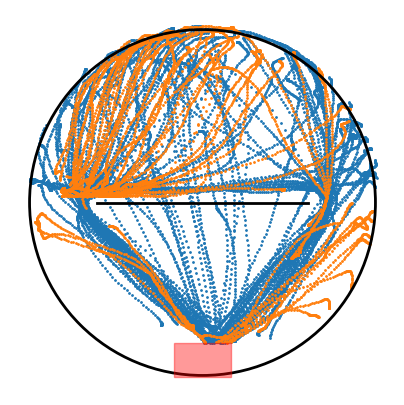

In [9]:
"""Find the homing starts and ends
Subselect complete homings"""

# starts of homings & escapes
starts = np.where(np.diff(h_e_bool.astype(int)) > 0)[0] + 1
ends = np.where(np.diff(h_e_bool.astype(int)) < 0)[0] + 1
homie_lengths = ends - starts
counter, h_start, e_start = 0, np.full(len(homie_lengths), 0), np.full(len(homie_lengths)+1, False)
for i, h in enumerate(homie_lengths):
    if full_e_bool[starts[i]]:
        e_start[i] = True # a bool that tells us which one of the h_starts are escapes
    h_start[i] = counter 
    counter += h
h_start = np.append(h_start, len(h_cond)) # a list of the start indices of homings + escapes in the homing/escape time period
e_bool = full_e_bool[h_e_bool] # a boolean that tells us which periods of the homing/escape are escapes

# where did the mouse start and end
y_start = Y[h_start[:-1]]
y_end = Y[h_start[1:]-1]
long_homie_bool = np.full(len(X), False)
homie_id = np.full(len(X), 0) # a vector that increases with each homing
for h, (s,e) in enumerate(zip(y_start, y_end)):
    homie_id[h_start[h]:h_start[h+1]] = h
    if (s < 512) & (e > 700):
        long_homie_bool[h_start[h]:h_start[h+1]] = True

fig, axs = plt.subplots(1, 1, figsize = (5, 5))
axs.scatter(X[long_homie_bool], Y[long_homie_bool], s = 1)
axs.scatter(X[~long_homie_bool], Y[~long_homie_bool], s = 1)
# Add center circle
circle = plt.Circle((512, 512), 460, color='k', fill=False, linewidth=2)
axs.add_patch(circle)
axs.plot([512-280,512+280], [512,512], 'k', linewidth=2)

# Add red transparent square
square = patches.Rectangle((437, 886), 150, 90, color='r', alpha=0.4)
axs.add_patch(square)

# Remove ticks and labels for a clean look
axs.set_xlim(0, 1024)
axs.set_ylim(0, 1024)
axs.set_xticks([])
axs.set_yticks([])
axs.set_frame_on(False)
axs.set_aspect('equal')
axs.invert_yaxis()

RH Warning: Overwriting file. File: \\ceph-gw02.hpc.swc.ucl.ac.uk\branco\Jasmine_Laurence\summary_plots\Cosyne\JAL6_flip4_21mar_homing_escape_barrier.pdf already exists.


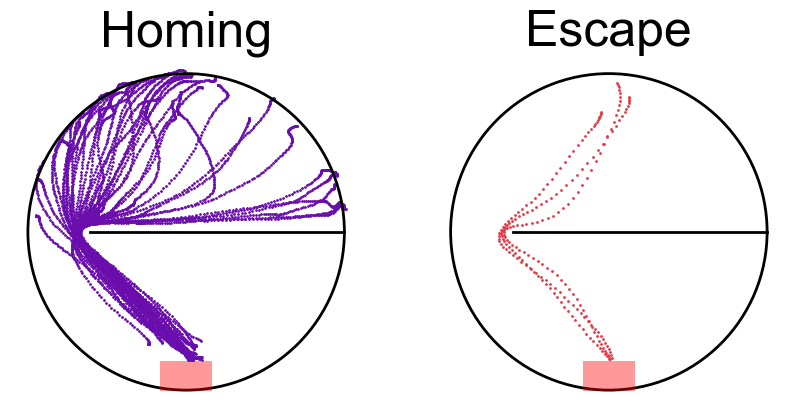

In [284]:
"""Make a plot of all the homings and one of all the escapes in this session + condition"""
%autoreload 2
c = 1

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for i in range(len(h_start)-1):
    start = h_start[i]
    length = homie_lengths[i]
    if long_homie_bool[start] & (h_cond[start] == c):
        # Extract the XY positions for this trial
        x_trial = X[start:start+length]
        y_trial = Y[start:start+length]

        # Set limits and plot XY trajectory
        if e_bool[start]:
            axs[1].scatter(x_trial, y_trial, s = 1, c = escape_color)
        else:
            axs[0].scatter(x_trial, y_trial, s = 1, c = homing_color)

for i in [0,1]:
    # Add center circle
    circle = plt.Circle((512, 512), 460, color='k', fill=False, linewidth=2)
    axs[i].add_patch(circle)
    axs[i].plot([512-280,512+460], [512,512], 'k', linewidth=2)

    # Add red transparent square
    square = patches.Rectangle((437, 886), 150, 90, facecolor='r', alpha=0.4, edgecolor=None, linewidth=0)
    axs[i].add_patch(square)

    # Remove ticks and labels for a clean look
    axs[i].set_xlim(0, 1024)
    axs[i].set_ylim(0, 1024)
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].set_frame_on(False)
    axs[i].set_aspect('equal')
    axs[i].invert_yaxis()

axs[0].set_title('Homing')
axs[1].set_title('Escape')

# Initialize the Figure_Saver
figure_saver = Figure_Saver(dir_save=save_path, format_save=["pdf"], overwrite = True)
figure_saver.save(fig, name_file=session_name + '_homing_escape_' + c_names[c])

RH Warning: Overwriting file. File: \\ceph-gw02.hpc.swc.ucl.ac.uk\branco\Jasmine_Laurence\summary_plots\Cosyne\JAL6_flip4_21mar_pattern_heatmap_barrier_3.pdf already exists.


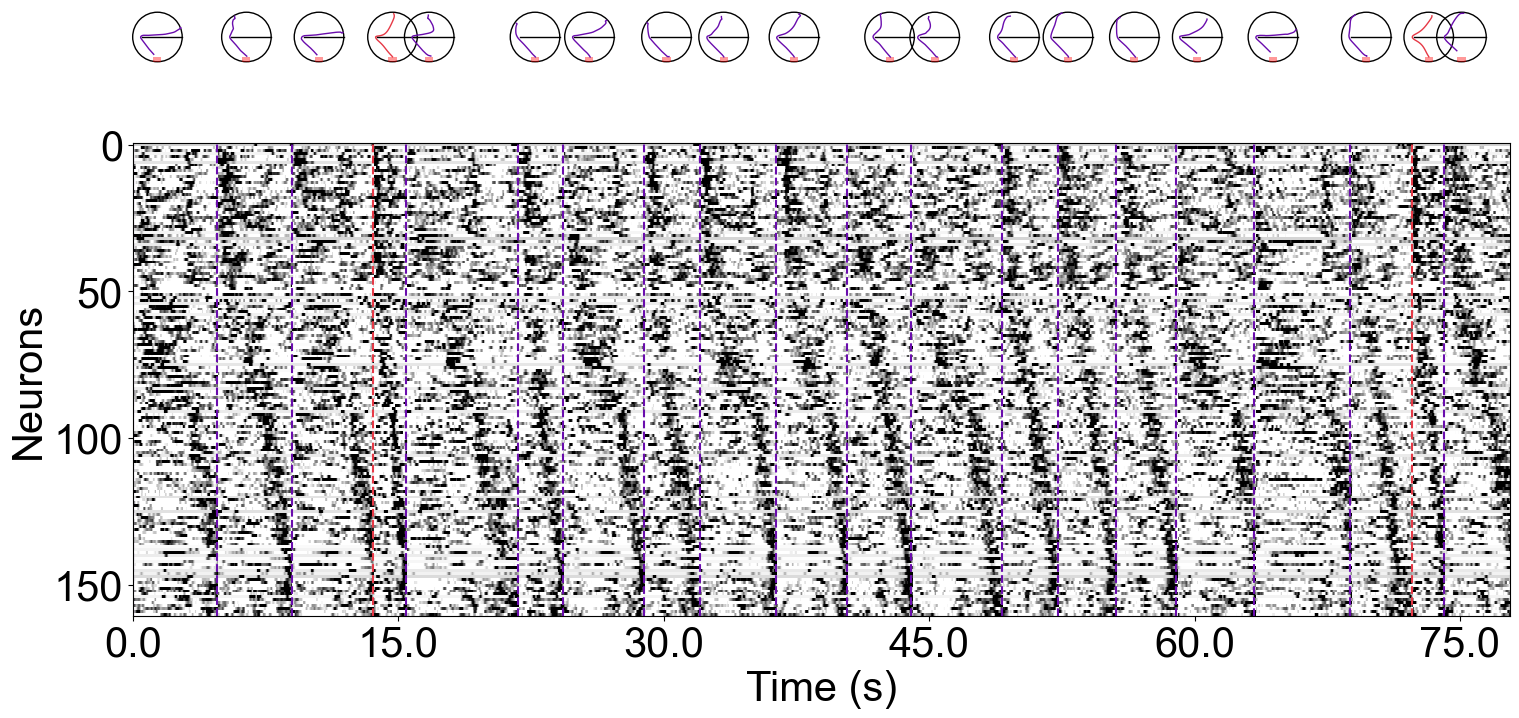

In [13]:
"""Make a heatmap of the homing data - separate by condition"""

width = 350 / 25.4 # mm to inches
height = 200 / 25.4 # mm to inches

c = 1

# Define trial start times (Example: 5 trials at arbitrary points)
n_trials = 20 # max is len(h_start)-1

homie_starts_this_c = np.append(0,np.where(np.diff(homie_id[long_homie_bool & (h_cond == c)]) > 0)[0])
time = homie_starts_this_c[n_trials]

# pull out neural activity for this condition
neural_matrix = fcm[h_e_bool & (cond == c),:] # select the homing and escape periods for the condition
neural_matrix = neural_matrix[:,sig_cells[:,c]] # select the cells that are sig in the condition
neural_matrix = zscore(neural_matrix[long_homie_bool[h_cond == c],:], axis = 0)
# neural_matrix = neural_matrix[long_homie_bool[h_cond == c],:] - np.nanmin(neural_matrix[long_homie_bool[h_cond == c],:], axis = 0)
# neural_matrix = neural_matrix/np.nanmax(neural_matrix, axis = 0)

# sort the cells by preferred tuning
isort = np.argsort(preferred_tuning[sig_cells[:,c],c])

# Set up figure with gridspec (one row for XY plots, one for heatmap)
fig = plt.figure(figsize=(width, height))
gs = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[1, 7], hspace=0.05)

# Compute trial centers
trial_centers = homie_starts_this_c[:n_trials] + (homie_lengths[:n_trials] // 2)

# Normalize centers for gridspec alignment (convert to relative positions)
trial_rel_positions = trial_centers / time
size = 0.07

# Create the heatmap
ax_heatmap = fig.add_subplot(gs[1], position=[0, 0.1, trial_rel_positions[-1] + (size/2), .6])
ax_heatmap.imshow(neural_matrix[:time,isort].T, vmin=-.5, vmax=1.5, cmap="gray_r", aspect="auto", interpolation="none")

# Create a separate row of subplots for XY position plots
gs_top = gridspec.GridSpecFromSubplotSpec(1, n_trials, subplot_spec=gs[0], wspace=0.008)

counter = 0
for i in range(len(h_start)-1):
    
    start = h_start[i]
    length = homie_lengths[i]

    if long_homie_bool[start] & (h_cond[start] == c) & (counter < n_trials):
        ax_xy = fig.add_subplot(gs_top[counter], position=[trial_rel_positions[counter] - (size/2), 0.8, size, size])  # Adjust width & height as needed
        # Extract the XY positions for this trial
        x_trial = X[start:start+length]
        y_trial = Y[start:start+length]

        # Set limits and plot XY trajectory
        if e_bool[start]:
            ax_xy.plot(x_trial, y_trial, color = escape_color, linewidth=1)
            # Add vertical lines for trial starts
            ax_heatmap.axvline(x=homie_starts_this_c[counter], color = escape_color, linestyle='--')
        else:
            ax_xy.plot(x_trial, y_trial, color = homing_color, linewidth=1)
            ax_heatmap.axvline(x=homie_starts_this_c[counter], color=homing_color, linestyle='--')

        ax_xy.set_xlim(0, 1024)
        ax_xy.set_ylim(0, 1024)

        # Add center circle
        circle = plt.Circle((512, 512), 460, color='k', fill=False, linewidth=1)
        ax_xy.add_patch(circle)
        ax_xy.plot([512-280,512+460], [512,512], 'k', linewidth=1)
        # Add red transparent square
        square = patches.Rectangle((437, 886), 150, 90, facecolor='r', alpha=0.4, edgecolor=None, linewidth=0)
        ax_xy.add_patch(square)

        # Remove ticks and labels for a clean look
        ax_xy.set_xticks([])
        ax_xy.set_yticks([])
        ax_xy.set_frame_on(False)
        ax_xy.set_aspect('equal')
        ax_xy.invert_yaxis()
        counter += 1

# Convert x-axis ticks to seconds
ax_heatmap.set_xticks(np.arange(0, time, 15*40))  # Set ticks at equal intervals
# Convert time indices to seconds
time_seconds = np.arange(time) / 40
ax_heatmap.set_xticklabels(np.round(np.arange(0, time_seconds[-1], 15), 1))  # Convert to seconds

ax_heatmap.set_ylabel("Neurons")
ax_heatmap.set_xlabel("Time (s)")

# Initialize the Figure_Saver
figure_saver = Figure_Saver(dir_save=save_path, format_save=["pdf"], overwrite = True, font_size=30)
figure_saver.save(fig, name_file=session_name + '_pattern_heatmap_' + c_names[c] + '_3')